# Week 6 — Data Cleaning
## Reproducing a key analysis: HIV diagnosis rates vs Social Vulnerability (SVI)

**Big idea:** We’ll take two messy real datasets and reproduce a core finding seen across the literature:
communities with higher **social vulnerability** tend to have higher **HIV diagnosis rates**.

**What you will practice**
- Inspecting raw data and identifying problems
- Cleaning common data issues (types, missingness, suppressed values, IDs)
- Aggregation (tract → county)
- Joining/merging datasets safely
- Summarizing results with groupby + statistics + simple plots

**Datasets used**
- County-level HIV diagnosis data (2022) with **rate per 100,000**
- CDC/ATSDR **SVI 2022** data at **census tract level** (we will aggregate to county)

## 0) Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1) Load the data

We’ll load the two files you already downloaded.

- HIV file: `hiv_diagnoses_2022.csv`
- SVI file: `SVI_2022_US.csv`

In [5]:
hiv_raw = pd.read_csv("hiv_diagnoses_2022.csv")
svi_raw = pd.read_csv("SVI_2022_US.csv")


In [6]:
hiv_raw.head()

,Indicator,Year,Geography,FIPS,Cases,Rate per 100000
0,HIV diagnoses,2022,"Abbeville County, SC",45001,Data suppressed,Data suppressed
1,HIV diagnoses,2022,"Acadia Parish, LA",22001,12,25.8
2,HIV diagnoses,2022,"Accomack County, VA",51001,Data suppressed,Data suppressed
3,HIV diagnoses,2022,"Ada County, ID",16001,15,3.4
4,HIV diagnoses,2022,"Adair County, IA",19001,0,0


In [7]:
svi_raw.head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga County,1001020100,Census Tract 201; Autauga County; Alabama,3.793569,1865,368,...,2.4,3.4,0.0,2.0,0.0,2.0,5.5,4.2,0.0,2.0
1,1,Alabama,AL,1001,Autauga County,1001020200,Census Tract 202; Autauga County; Alabama,1.282174,1861,396,...,0.0,2.0,0.0,2.0,0.0,2.0,7.3,6.3,0.4,0.9
2,1,Alabama,AL,1001,Autauga County,1001020300,Census Tract 203; Autauga County; Alabama,2.065364,3492,593,...,0.3,0.5,0.0,1.1,0.0,1.1,4.2,5.2,0.0,1.1
3,1,Alabama,AL,1001,Autauga County,1001020400,Census Tract 204; Autauga County; Alabama,2.464984,3987,411,...,0.6,0.6,0.2,0.3,0.0,0.9,2.9,2.6,0.0,0.9
4,1,Alabama,AL,1001,Autauga County,1001020501,Census Tract 205.01; Autauga County; Alabama,2.395243,4121,709,...,2.4,4.1,0.0,0.9,0.0,0.9,1.0,1.3,0.0,0.9


## 2) First look: inspection checklist

Always do these **before** cleaning:
- `shape` (rows, columns)
- `info()` to check types (strings vs numbers)
- Missingness counts
- Duplicates

In [35]:
def inspect_df(df, name="df"):
    print("shape:", df.shape)
    print("\ninfo:")
    df.info()

In [36]:
inspect_df(hiv_raw, "hiv_raw")

shape: (3231, 6)

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3231 entries, 0 to 3230
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Indicator        3231 non-null   object
 1   Year             3231 non-null   int64 
 2   Geography        3231 non-null   object
 3   FIPS             3231 non-null   int64 
 4   Cases            3231 non-null   object
 5   Rate per 100000  3231 non-null   object
dtypes: int64(2), object(4)
memory usage: 151.6+ KB


In [37]:
inspect_df(svi_raw, "svi_raw")

shape: (84120, 158)

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84120 entries, 0 to 84119
Columns: 158 entries, ST to MP_OTHERRACE
dtypes: float64(75), int64(79), object(4)
memory usage: 101.4+ MB


## 3) Quick conceptual block: what is SVI

**SVI = Social Vulnerability Index (CDC/ATSDR).**  
It’s a way to summarize how vulnerable a community may be to external stresses (e.g., disasters, outbreaks),
based on social and structural factors.

SVI is built from **16 variables** grouped into **4 themes**:
1. **Theme 1: Socioeconomic status**
2. **Theme 2: Household composition & disability**
3. **Theme 3: Minority status & language**
4. **Theme 4: Housing type & transportation**

Key columns in the SVI dataset:
- `RPL_THEMES`: **overall percentile rank** from 0 to 1 (higher = more vulnerable)
- `RPL_THEME1`–`RPL_THEME4`: theme percentile ranks (0–1)
- `E_TOTPOP`: tract population estimate (useful for weighting)

**Percentile rank interpretation**
- `0.90` means this tract is more vulnerable than ~90% of tracts (nationally, if it’s a national file)

**Why SVI matters for health**
SVI captures structural conditions that influence access to care, prevention resources, housing stability, transportation, etc.
So it’s often used to explore patterns in infectious disease and outcomes (including HIV diagnosis rates).

## 4) Clean the HIV county dataset

Problems we already see:
- `Cases` and `Rate per 100000` are not purely numeric because they're objects
- Geography is a string; we want the real join key: FIPS

We will:
2) Convert rates in a particular column to numeric from object

In [39]:
# make a copy so we don't change the original
hiv = hiv_raw.copy()

# convert to correct datatypes
# convert FIPS to string
hiv["FIPS"] = hiv["FIPS"].astype(str)

# convert numeric columns
hiv["Cases_num"] = pd.to_numeric(hiv["Cases"], errors="coerce")
hiv["Rate_per_100k"] = pd.to_numeric(hiv["Rate per 100000"], errors="coerce")

## 5) Clean the SVI tract dataset

Important reality:
- This SVI file is **census tract level**, not county level.
- The `FIPS` column here is a tract identifier (state+county+tract).  
- 5-digit Federal Information Processing Series number that uniquely identifies counties and county-equivalent entities in the US.

So now we're going to extract county FIPS as the first 5 characters

In [23]:
# make a copy so we don't change the original
svi = svi_raw.copy()

# convert FIPS to text
svi["FIPS"] = svi["FIPS"].astype(str)

# county FIPS = first 5 digits of tract FIPS
svi["county_fips"] = svi["FIPS"].str[:5]

svi[["FIPS","county_fips"]].head()

,FIPS,county_fips
0,1001020100,10010
1,1001020200,10010
2,1001020300,10010
3,1001020400,10010
4,1001020501,10010


## 6) Aggregation: tract → county

We want to merge county HIV rates with SVI, but:
- HIV is at **county level**
- SVI is at **tract level**

What this means: 
- The HIV data has one row per county.
- The SVI data has many rows per county (one per census tract).

The SVI dataset has multiple census tracts inside each county.
But we need one SVI value per county. So we:

- group rows by county
- summarize each group with a statistic (mean)

This is exactly what groupby + agg does.

## Variable we'll be summarizing:
RPL_THEMES = the overall Social Vulnerability Index (SVI) percentile rank
- It tells you how socially vulnerable a place is compared to other places.

🧱 How SVI is built

SVI combines 4 areas (themes) of social vulnerability:

- Socioeconomic status
- Household composition & disability
- Minority status & language
- Housing & transportation

Each area gets a score → then they’re combined into one overall SVI. That overall score is RPL_THEMES.

### Groupby Function Structure:
```python
df.groupby(group_column).agg(new_column=("source_column", "statistic"))
```

In [26]:
# average SVI across tracts within each county
county_svi = (
    svi
    .groupby("county_fips", as_index=False)
    .agg(
        rpl_themes=("RPL_THEMES", "mean")
    )
)

county_svi.head()

,county_fips,rpl_themes
0,10001,-23.797659
1,10003,-6.508240
2,10005,-13.107241
3,10010,0.366276
4,10030,0.379523


## 7) Merge HIV (county) + SVI (county)

Now the merge is aligned:
- HIV dataset → one row per county
- SVI dataset → one row per county
- Both have the same county identifier: FIPS.


We want to combine them into one table so each county has:
- HIV rate
- SVI value

This is called a join (or merge).

### What is a join?
A join matches rows from two tables using a shared column (a key). In our case, this shared column is FIPS

**Left Join**
- keep all rows from the left table
- and add matching data from the right table
- This is like merging a patient vitals table with a patient lab table using patient ID. After the merge, each patient row has both vitals and labs.

We will choose HIV as the left table because:
- we want to keep every county that has HIV data even if SVI is missing
- Essentially, HIV is the table that we want to ADD to!


### Merge Function Structure:
```python
left_table.merge(
    right_table,
    left_on="key",
    right_on="key",
    how="left"
)
```

In a merge, pandas needs to know:
- **left on**: which column in the left table
- **right on**: matches which column in the right table

In [40]:
hiv_svi = hiv.merge(
    county_svi,
    left_on="FIPS",
    right_on="county_fips",
    how="left", # specifies that it's a left join
)

print("Rows:", len(hiv_svi))
hiv_svi.head()

Rows: 3231


,Indicator,Year,Geography,FIPS,Cases,Rate per 100000,Cases_num,Rate_per_100k,county_fips,rpl_themes
0,HIV diagnoses,2022,"Abbeville County, SC",45001,Data suppressed,Data suppressed,NaN,NaN,45001,0.566457
1,HIV diagnoses,2022,"Acadia Parish, LA",22001,12,25.8,12.0,25.8,22001,0.589610
2,HIV diagnoses,2022,"Accomack County, VA",51001,Data suppressed,Data suppressed,NaN,NaN,51001,-76.301615
3,HIV diagnoses,2022,"Ada County, ID",16001,15,3.4,15.0,3.4,16001,0.276527
4,HIV diagnoses,2022,"Adair County, IA",19001,0,0,0.0,0.0,19001,0.313700


### 7.1 Investigate unmatched counties (if any)
When merges fail, it’s almost always the key. We inspect unmatched rows before moving on.

In [41]:
unmatched = hiv_svi[hiv_svi["rpl_themes"].isna()]
unmatched

,Indicator,Year,Geography,FIPS,Cases,Rate per 100000,Cases_num,Rate_per_100k,county_fips,rpl_themes
8,HIV diagnoses,2022,"Adams County, CO",8001,52,11.9,52.0,11.9,NaN,NaN
21,HIV diagnoses,2022,"Adjuntas Municipio, PR",72001,0,0,0.0,0.0,NaN,NaN
22,HIV diagnoses,2022,"Aguada Municipio, PR",72003,Data suppressed,Data suppressed,NaN,NaN,NaN,NaN
23,HIV diagnoses,2022,"Aguadilla Municipio, PR",72005,Data suppressed,Data suppressed,NaN,NaN,NaN,NaN
24,HIV diagnoses,2022,"Aguas Buenas Municipio, PR",72007,Data suppressed,Data suppressed,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3217,HIV diagnoses,2022,"Yolo County, CA",6113,16,8.4,16.0,8.4,NaN,NaN
3224,HIV diagnoses,2022,"Yuba County, CA",6115,Data suppressed,Data suppressed,NaN,NaN,NaN,NaN
3225,HIV diagnoses,2022,"Yukon-Koyukuk Census Area, AK",2290,Data suppressed,Data suppressed,NaN,NaN,NaN,NaN
3226,HIV diagnoses,2022,"Yuma County, AZ",4027,21,12.2,21.0,12.2,NaN,NaN


## 8) Extra! Analysis block: HIV rates vs overall SVI (RPL_THEMES)
Surbhi will cover this in more detail in a later lecture, but as a treat:
We will:
- Drop rows where HIV rate is missing 
- Plot a scatter (SVI percentile vs HIV rate)

In [44]:
# Drop all the null values
analysis = hiv_svi.dropna()

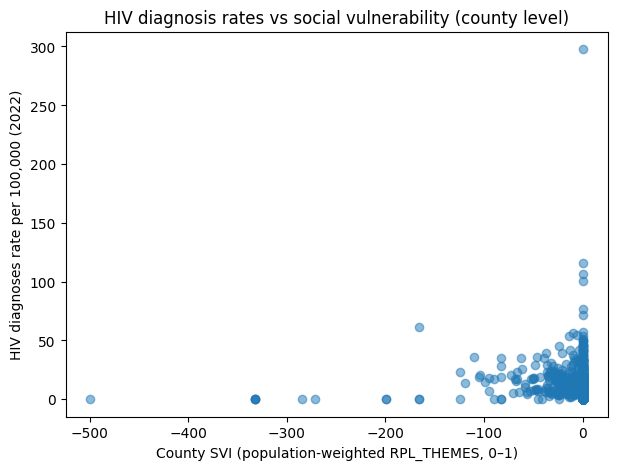

In [45]:
plt.figure(figsize=(7,5))
plt.scatter(analysis["rpl_themes"], analysis["Rate_per_100k"], alpha=0.5)
plt.xlabel("County SVI (population-weighted RPL_THEMES, 0–1)")
plt.ylabel("HIV diagnoses rate per 100,000 (2022)")
plt.title("HIV diagnosis rates vs social vulnerability (county level)")
plt.show()